Chapter 4: Implementing a GPT model from Scratch To Generate Text

In [ ]:
# 使用 importlib.metadata 查看已安装第三方库的版本号，用于检查环境是否满足教程要求
from importlib.metadata import version

# 【bug修复】原notebook这里错误地引入了与本教程完全无关的 selenium 依赖：
#   from selenium.webdriver.common.devtools.v150.tethering import unbind
# 该行代码未在后续任何地方被使用，且大概率因未安装 selenium 而抛出 ModuleNotFoundError，
# 因此已将其删除，不影响本notebook任何功能。

# 打印本章依赖的关键库版本：matplotlib（绘图）、torch（张量与神经网络）、tiktoken（GPT-2分词器）
print("matplotlib version:", version("matplotlib"))
print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))

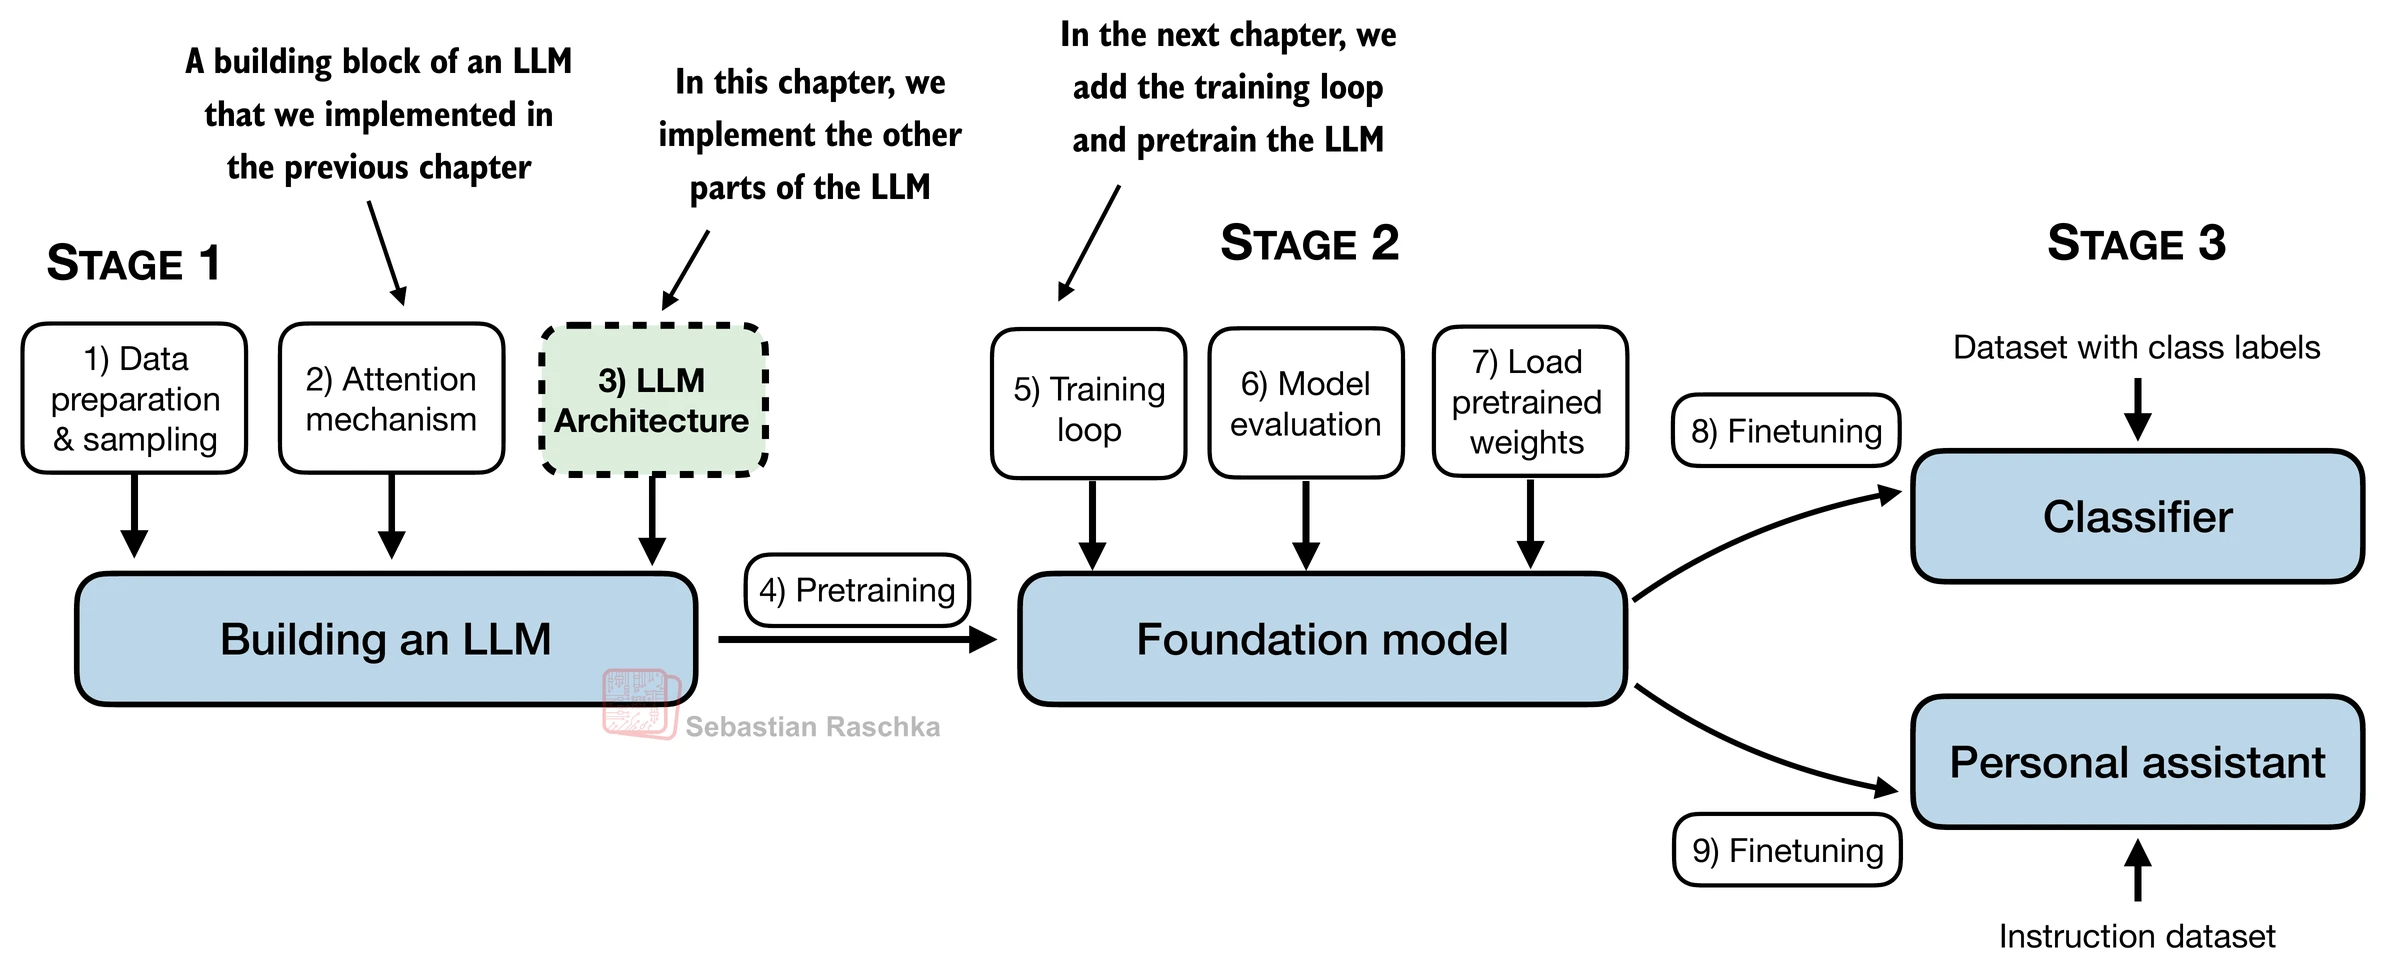

4.1 Coding an LLM architecture
Chapter 1 discussed models like GPT and Llama, which generate words sequentially and are based on the decoder part of the original transformer architecture
Therefore, these LLMs are often referred to as "decoder-like" LLMs
Compared to conventional deep learning models, LLMs are larger, mainly due to their vast number of parameters, not the amount of code
We'll see that many elements are repeated in an LLM's architecture
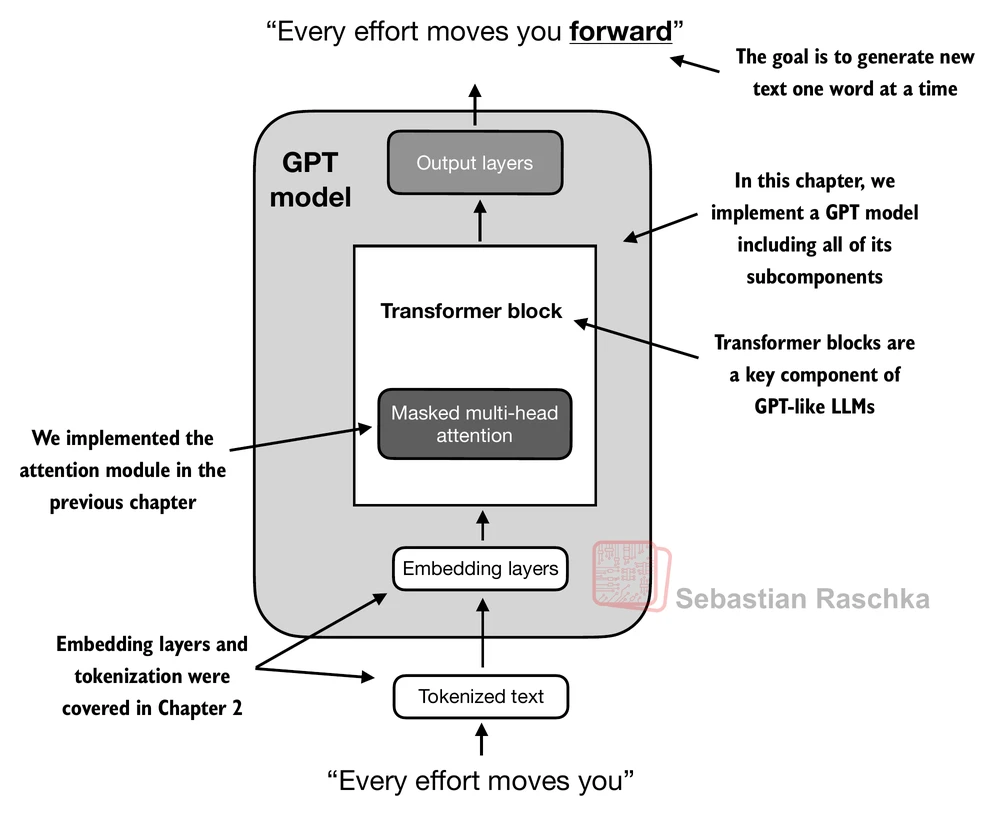

In [ ]:
# GPT-124M（约1.24亿参数）模型的超参数配置，后续 DummyGPTModel / TransformerBlock / GPTModel 等
# 都通过传入这个 cfg 字典来确定网络结构
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size  # 词表大小：分词器可能产生的不同token总数
    "context_length": 1024, # Context length  # 上下文长度：模型一次最多能处理的token数，决定位置嵌入表大小
    "emb_dim": 768,         # Embedding dimension  # 嵌入维度：每个token被映射成的向量长度
    "n_heads": 12,          # Number of attention heads  # 多头注意力的头数
    "n_layers": 12,         # Number of layers  # 堆叠的Transformer Block层数
    "drop_rate": 0.1,       # Dropout rate  # dropout比例，用于正则化防止过拟合
    "qkv_bias": False       # Query-Key-Value bias  # 计算Q/K/V的线性层是否使用偏置项
}

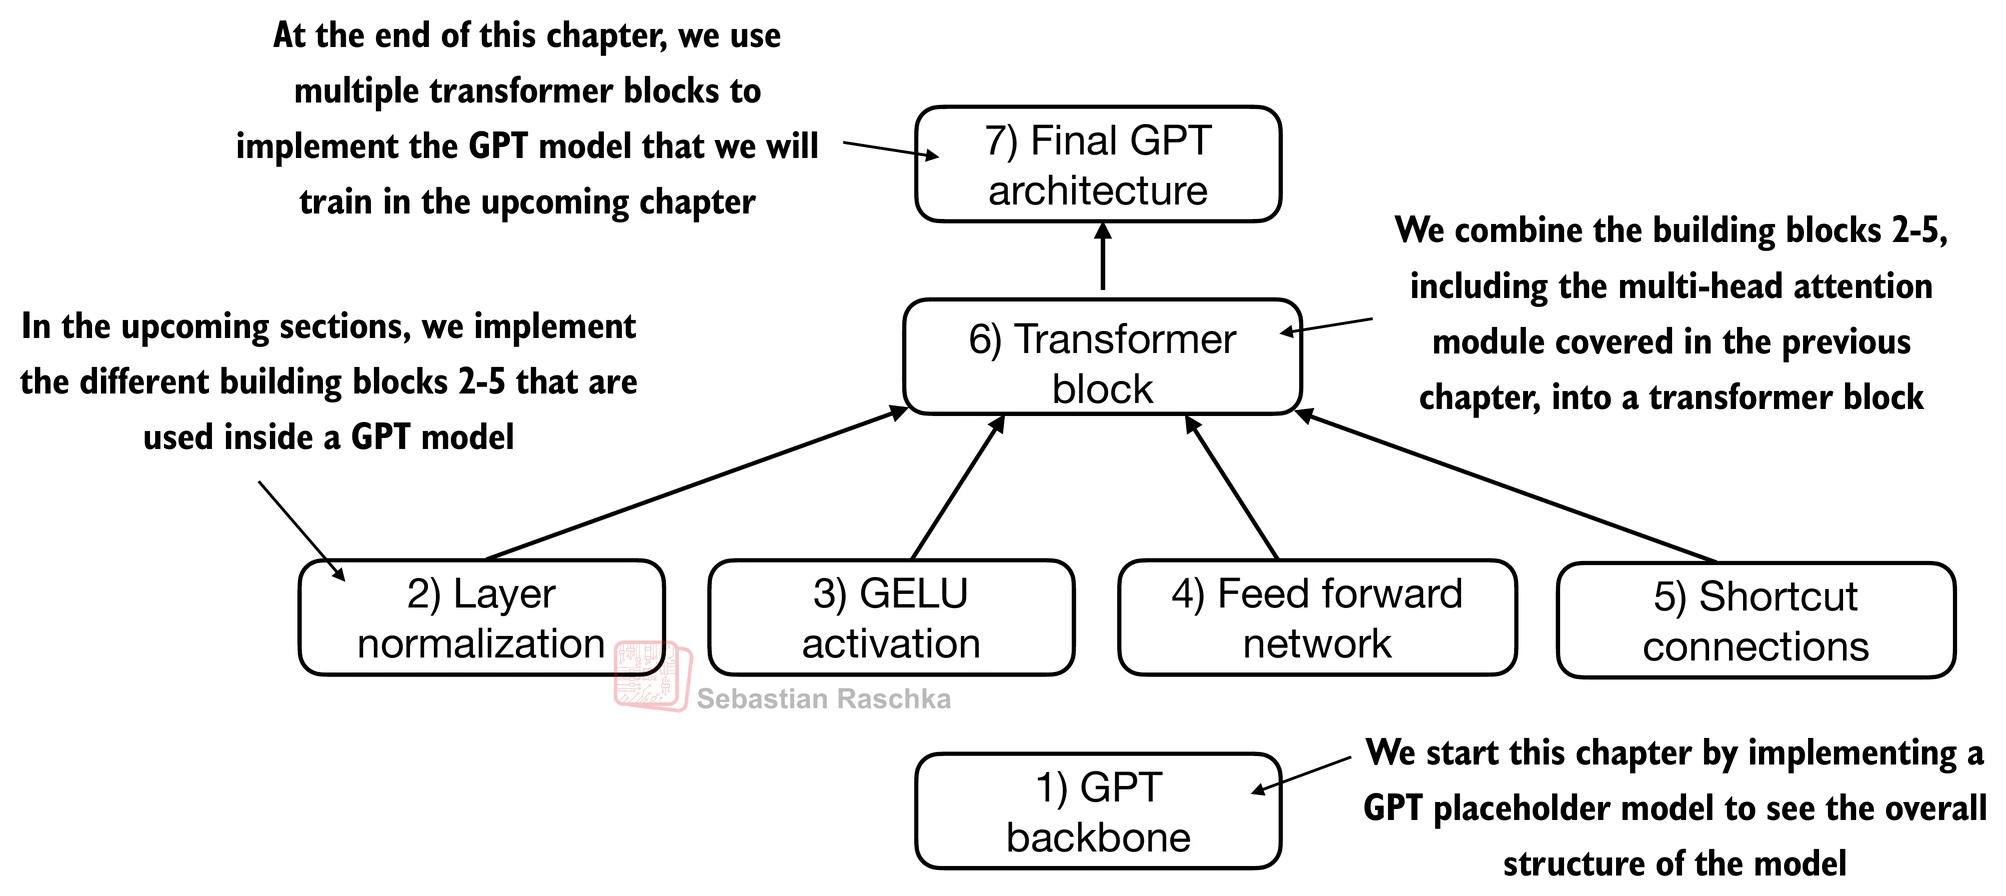

In [ ]:
import torch
import torch.nn as nn

# DummyGPTModel：GPT模型的“占位/骨架”版本。
# 目的是先跑通整体前向传播的数据流：token嵌入 -> 位置嵌入(相加) -> dropout -> 若干Transformer Block -> 最终归一化 -> 输出头(logits)，
# 其中 DummyTransformerBlock 和 DummyLayerNorm 暂时只是“透传”输入、不做任何真实计算的占位实现，
# 后续章节会替换为真正实现了注意力/前馈网络的 TransformerBlock 以及真正的 LayerNorm。
class DummyGPTModel(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        # token嵌入表，形状 [vocab_size, emb_dim]：把每个token id映射为一个 emb_dim 维向量
        self.tok_emb=nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
        # 位置嵌入表，形状 [context_length, emb_dim]：为序列中的每个位置学习一个位置向量
        self.pos_emb=nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        # 依次堆叠 n_layers 个（此处为占位的）Transformer Block
        self.trf_blocks =nn.Sequential(*[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"]) ])
        self.final_norm=DummyLayerNorm(cfg["emb_dim"])
        # 输出头：把 emb_dim 维隐藏状态线性映射回 vocab_size 维的logits（不使用偏置）
        self.out_head=nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )
    def forward(self, in_idx):
        # in_idx 形状: [batch_size, seq_len]，每个元素是一个token id
        batch_size, seq_len = in_idx.shape
        # tok_embeds 形状: [batch_size, seq_len, emb_dim]
        tok_embeds = self.tok_emb(in_idx)
        # 生成位置下标 [0, 1, ..., seq_len-1] 并查表得到位置嵌入
        # pos_embeds 形状: [seq_len, emb_dim]
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        # 广播相加：[batch_size, seq_len, emb_dim] + [seq_len, emb_dim] -> [batch_size, seq_len, emb_dim]
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)  # 占位Block不改变形状，仍是 [batch_size, seq_len, emb_dim]
        x = self.final_norm(x)
        # logits 形状: [batch_size, seq_len, vocab_size]
        logits = self.out_head(x)
        return logits

# 占位用的“假”Transformer Block：不做任何注意力/前馈计算，直接原样返回输入，
# 用于先验证整体forward流程能跑通、张量形状是否符合预期
class DummyTransformerBlock(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        # A simple placeholder
    def forward(self, x):
        # This block does nothing and just returns its input.
        return x

# 占位用的“假”LayerNorm：同样不做真正的归一化计算，直接原样返回输入
class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        # The parameters here are just to mimic the LayerNorm interface.

    def forward(self, x):
        # This layer does nothing and just returns its input.
        return x


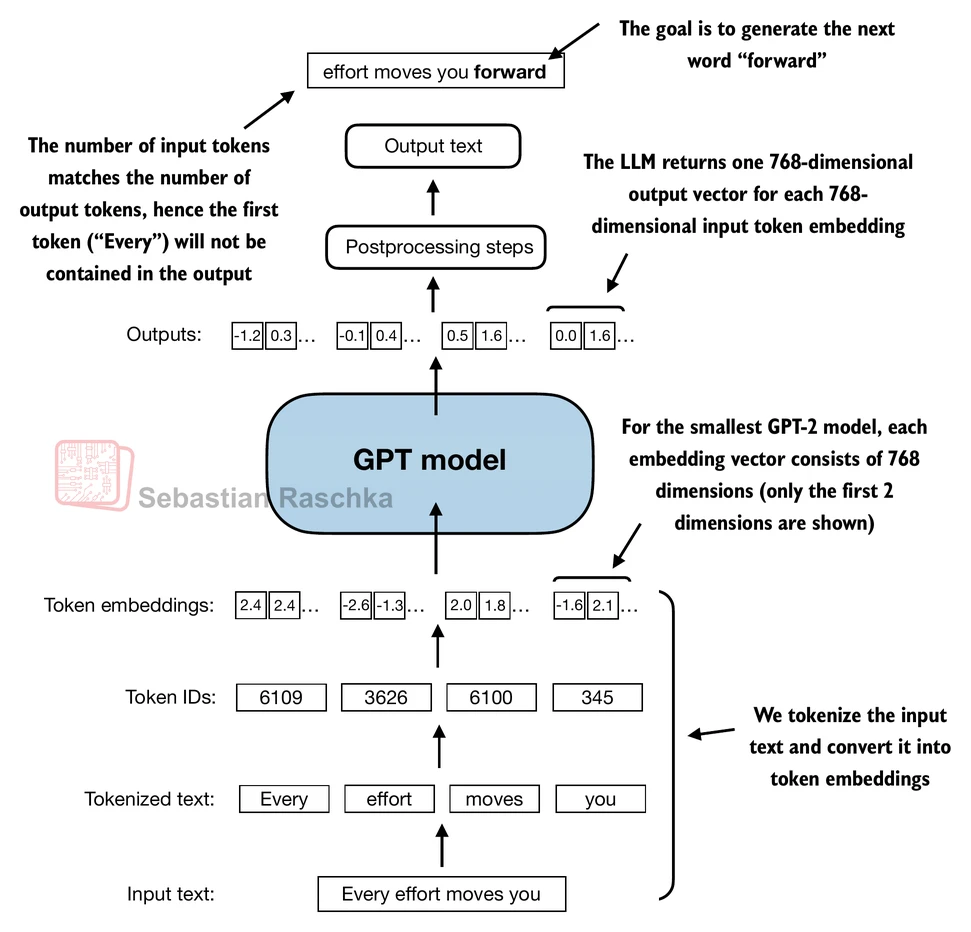

In [ ]:
import tiktoken

# 使用 tiktoken 加载 GPT-2 使用的 BPE（字节对编码）分词器
tokenizer = tiktoken.get_encoding("gpt2")

batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

# 将两条文本分别编码为token id列表，再转成张量，并加入batch列表
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
# 沿着新维度(dim=0)堆叠成一个batch，形状变为 [batch_size=2, seq_len]（这里两句token数相同）
batch = torch.stack(batch, dim=0)
print(batch)

In [ ]:
torch.manual_seed(123)
# 用DummyGPTModel（占位骨架版）对上面构造的batch做一次前向传播
model = DummyGPTModel(GPT_CONFIG_124M)

# logits 形状: [batch_size, seq_len, vocab_size]，即每个位置对词表中每个token的打分
logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

4.2 Normalizing activations with layer normalization
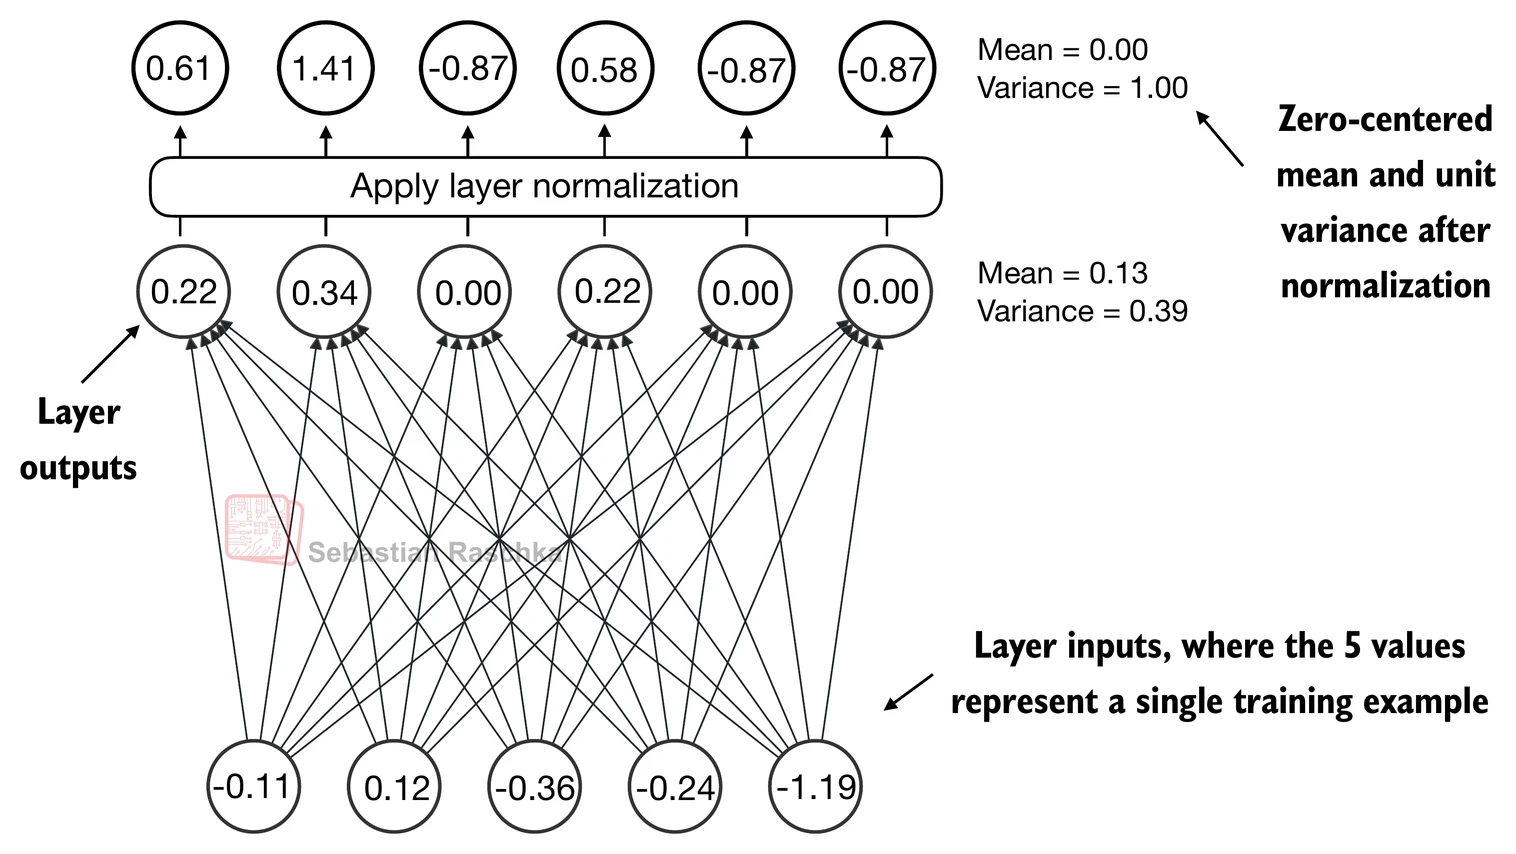

In [ ]:
torch.manual_seed(123)

# create 2 training examples with 5 dimensions (features) each
# 构造2个样本，每个样本5维特征，用来演示LayerNorm要解决的问题：不同样本/不同维度的激活值分布可能差异很大
batch_example = torch.randn(2, 5)

# 一个简单的线性层+ReLU，输出维度从5变为6
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)  # out 形状: [2, 6]
print(out)

In [ ]:
# 沿最后一维(特征维)计算均值和方差，keepdim=True 保留该维度(大小变为1)方便后续广播
mean = out.mean(dim=-1, keepdim=True)  # 形状: [2, 1]
var = out.var(dim=-1, keepdim=True)    # 形状: [2, 1]

print("Mean:\n", mean)
print("Variance:\n", var)

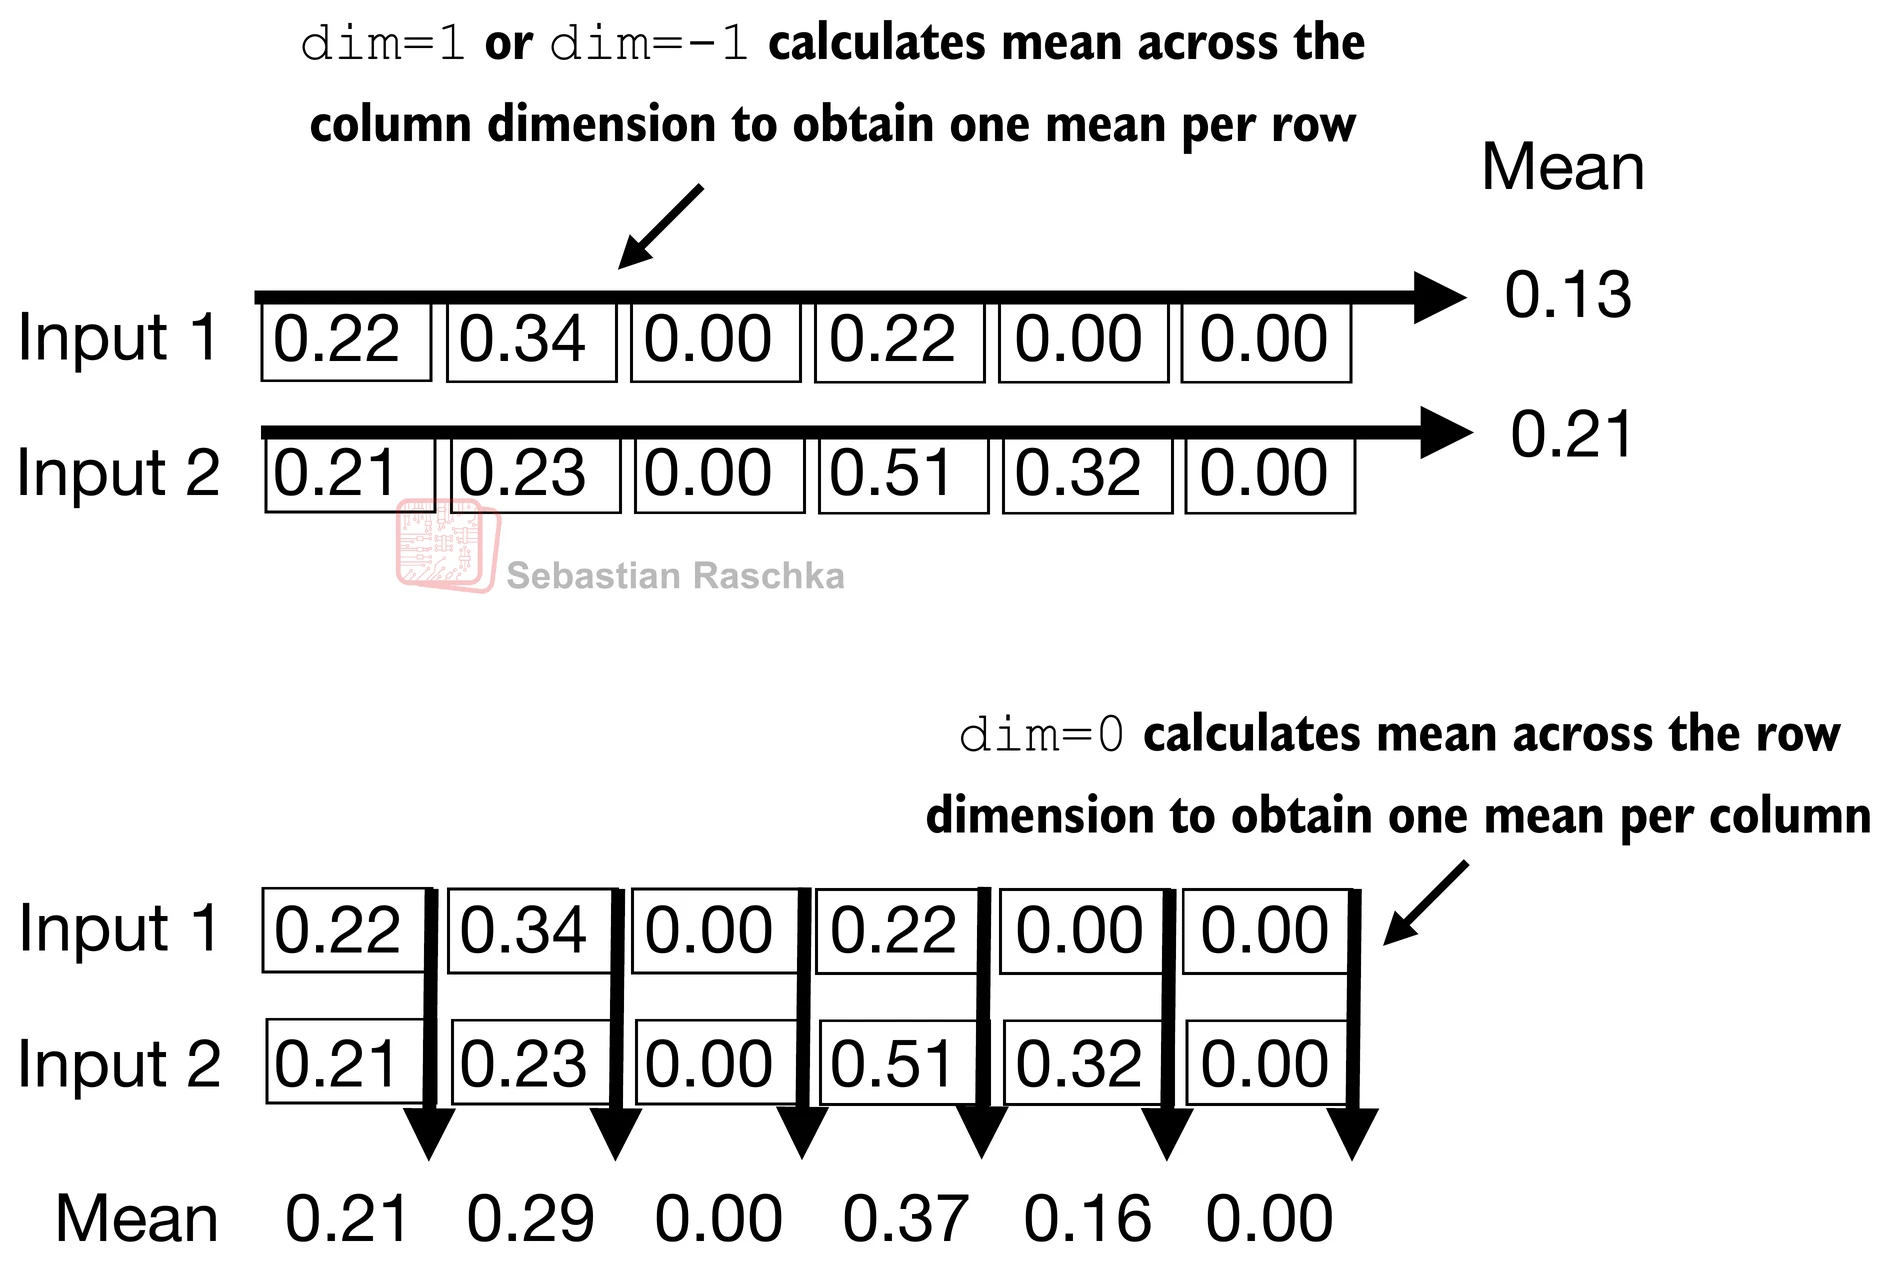

In [ ]:
# 手工实现层归一化：先减均值再除以标准差，使每个样本在特征维上均值为0、方差为1
out_norm = (out - mean) / torch.sqrt(var)
print("Normalized layer outputs:\n", out_norm)

# 验证归一化效果：重新计算均值和方差，应分别接近0和1
mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

In [ ]:
# 关闭科学计数法显示，方便直观查看均值是否真的接近0（否则会显示成类似 -1.9868e-08 这种形式）
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

In [ ]:
# 可训练的层归一化模块（真正在GPT中使用的版本）
class LayerNorm(nn.Module):
    def __init__(self,emb_dim):
        super().__init__()
        self.eps=1e-5  # 防止除以0的小常数
        # scale(缩放)和shift(平移)是可学习参数，初始为全1/全0，
        # 让模型在训练中可以自己学习是否需要、以及如何调整归一化后的分布
        self.scale=nn.Parameter(torch.ones(emb_dim))
        self.shift=nn.Parameter(torch.zeros(emb_dim))
    def forward(self, x):
        # x 形状通常为 [batch_size, seq_len, emb_dim]，在最后一维(emb_dim)上做归一化
        mean = x.mean(dim=-1, keepdim=True)
        # unbiased=False 表示使用有偏方差估计（除以N而非N-1），与GPT-2官方实现保持一致
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        # 归一化后再做一次可学习的缩放和平移，输出形状与输入相同
        return self.scale * norm_x + self.shift

In [ ]:
# 用真正的LayerNorm对前面的out重新归一化，emb_dim=6对应out的最后一维大小
ln=LayerNorm(emb_dim=6)
out_ln=ln(out)

In [ ]:
# 验证LayerNorm效果：均值应接近0，方差应接近1
mean=out_ln.mean(dim=-1,keepdim=True)
var=out_ln.var(dim=-1,unbiased=False,keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

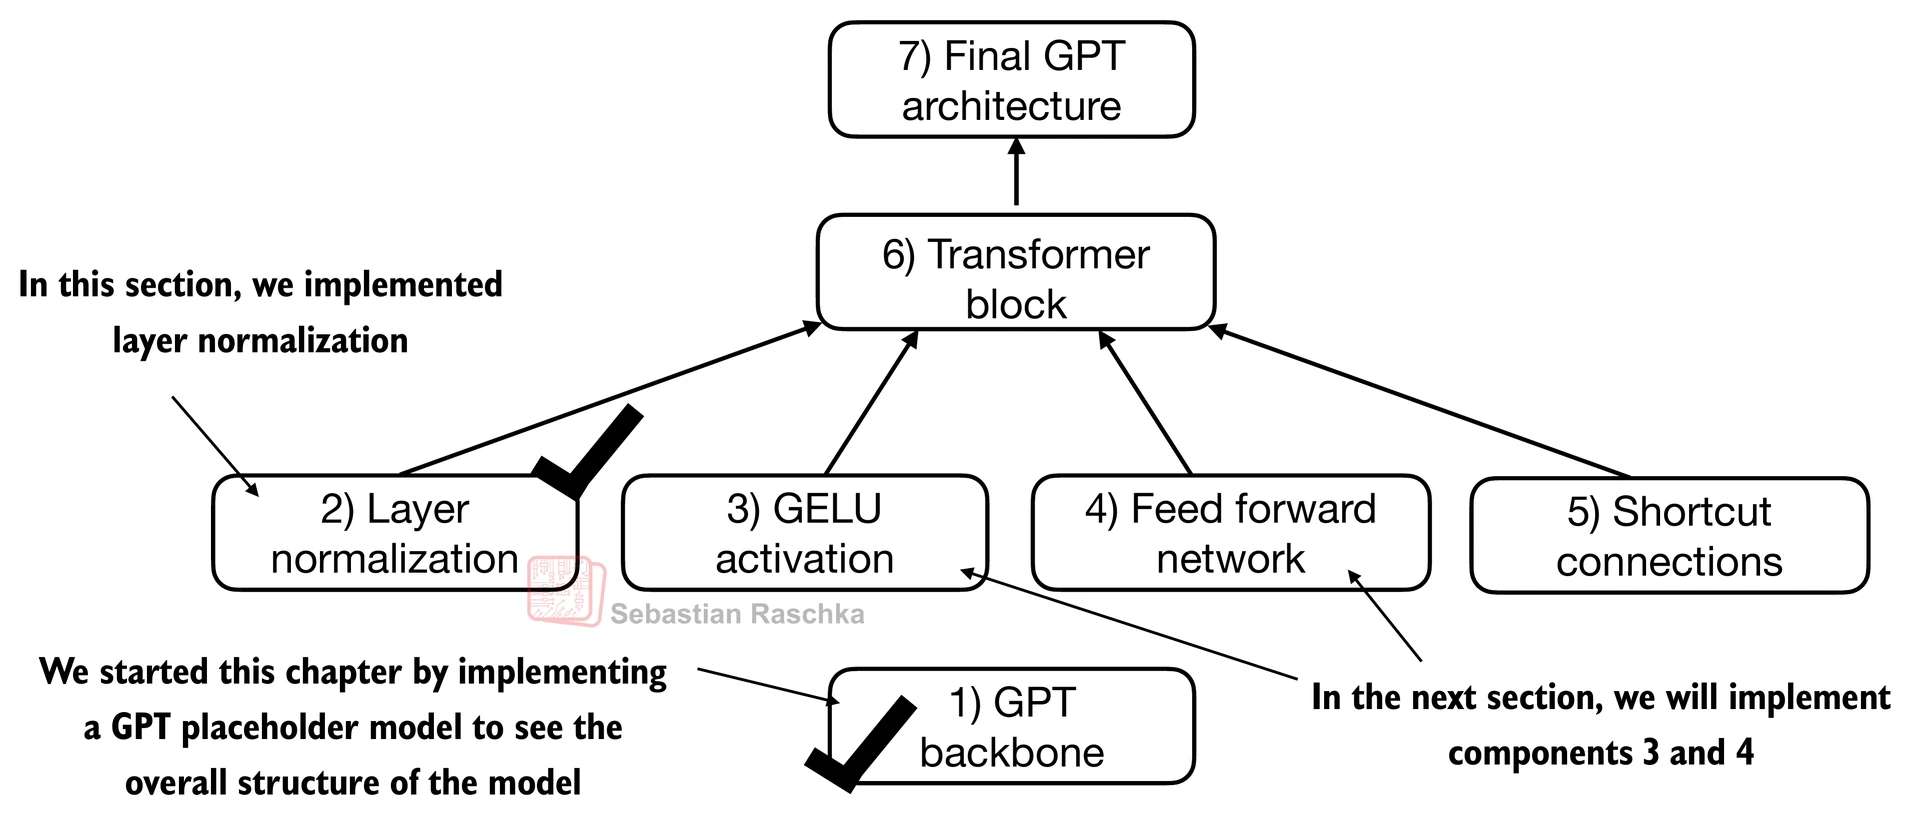

4.3 Implementing a feed forward network with GELU activations

In [ ]:
# GELU（Gaussian Error Linear Unit）激活函数，GPT系列常用，比ReLU更平滑
# 这里使用的是GELU的近似(tanh)实现，与原始GPT-2代码一致
class GELU(nn.Module):
    def  __init__(self):
        super().__init__()
    def forward(self,x):
        # 0.5 * x * (1 + tanh[ sqrt(2/pi) * (x + 0.044715 * x^3) ])
        return 0.5*x*(1+torch.tanh_(
            torch.sqrt(torch.tensor(2.0/torch.pi))*
            (x+0.044715*torch.pow(x,3))
        ))

In [ ]:
import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()
# Some sample data
# 在[-3, 3]区间均匀取100个点，分别过GELU和ReLU，画图对比两者形状差异
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# 前馈网络（FFN）：GPT每个Transformer Block中除了注意力之外的另一个核心子模块
# 结构为：Linear(emb_dim -> 4*emb_dim) -> GELU -> Linear(4*emb_dim -> emb_dim)
# 先升维再降维，让模型在更高维空间里做非线性变换，增强表达能力
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        # 输入输出形状相同: [batch_size, seq_len, emb_dim]
        return self.layers(x)

In [ ]:
# 打印配置中的嵌入维度，确认GPT_CONFIG_124M["emb_dim"]的取值(768)
print(GPT_CONFIG_124M["emb_dim"])

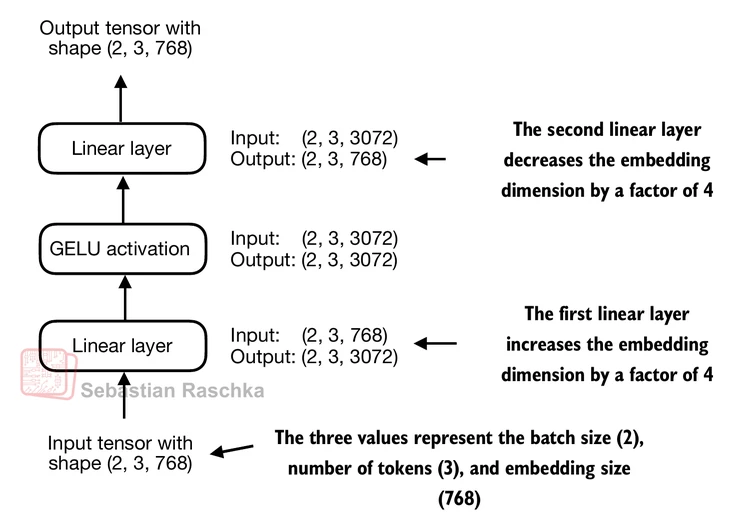

In [ ]:
ffn = FeedForward(GPT_CONFIG_124M)

# input shape: [batch_size, num_token, emb_size]
# 构造一个形状为 [2, 3, 768] 的随机输入，模拟 batch_size=2、序列长度=3、嵌入维度=768
x = torch.rand(2, 3, 768)
out = ffn(x)
print(out.shape)  # 应仍为 [2, 3, 768]：FFN不改变输入输出的形状

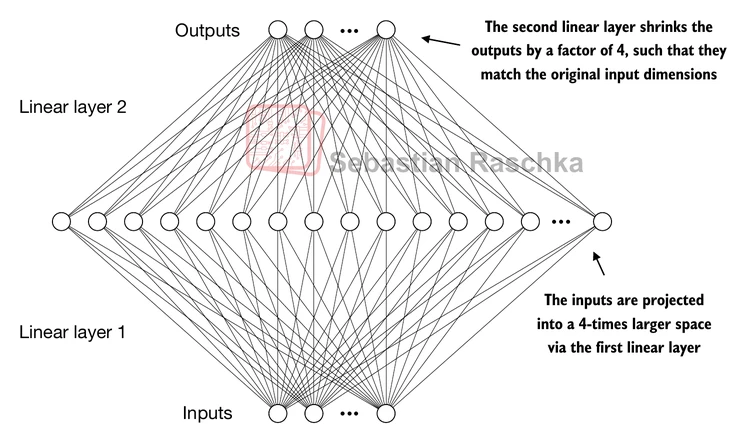
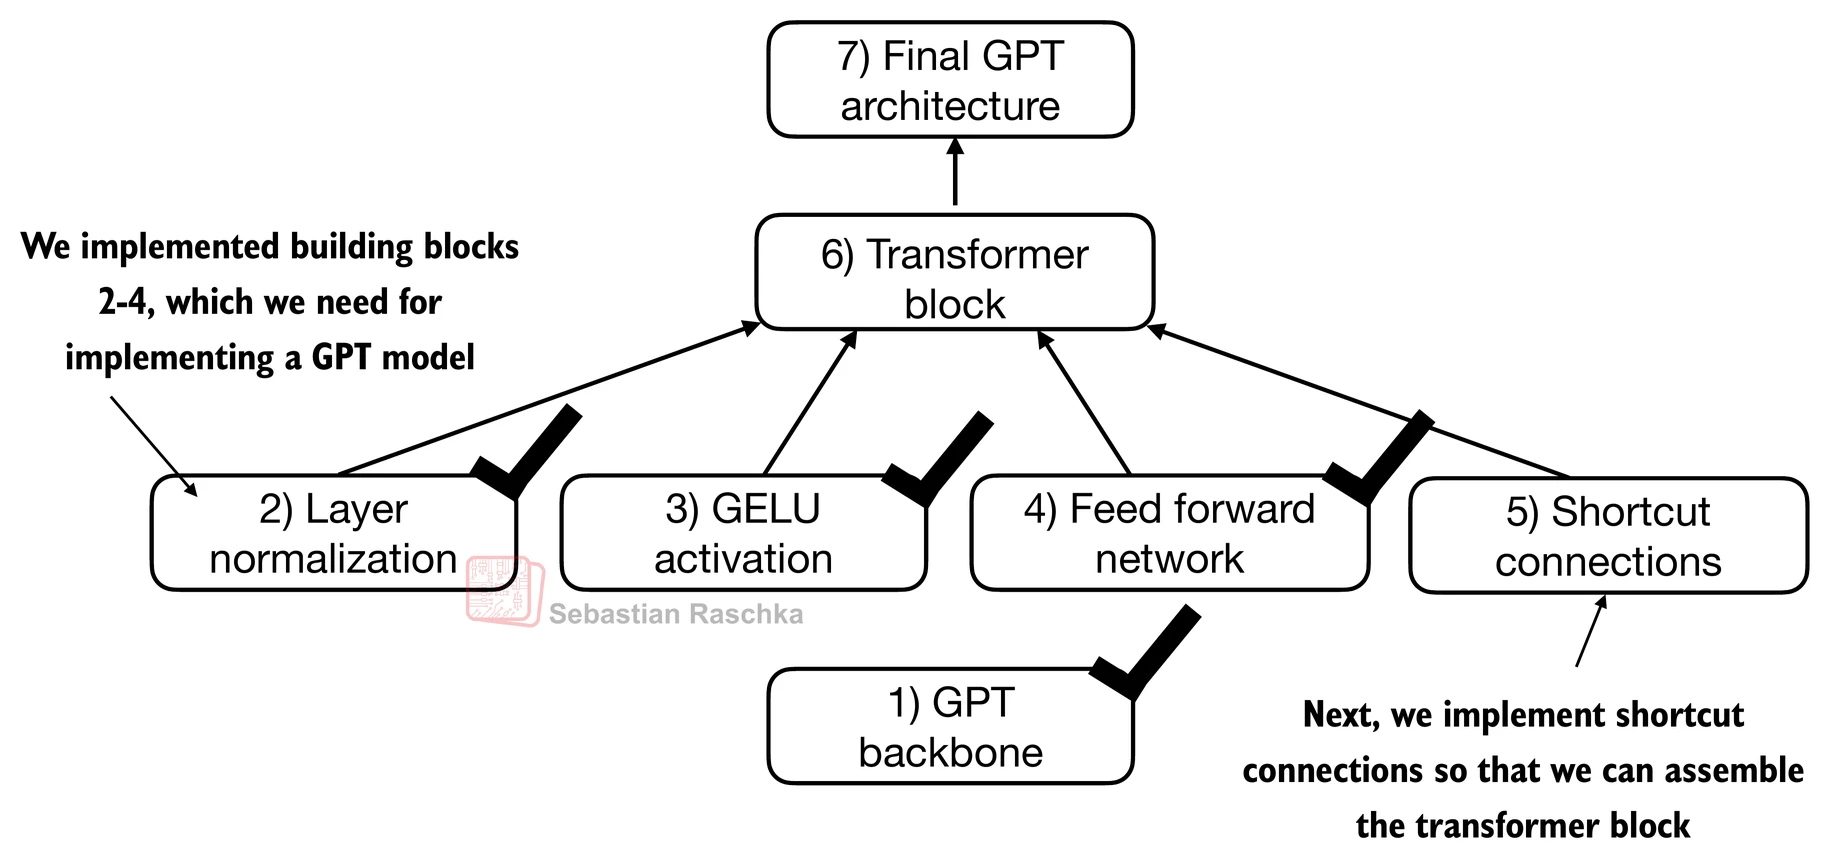

4.4 Adding shortcut connections
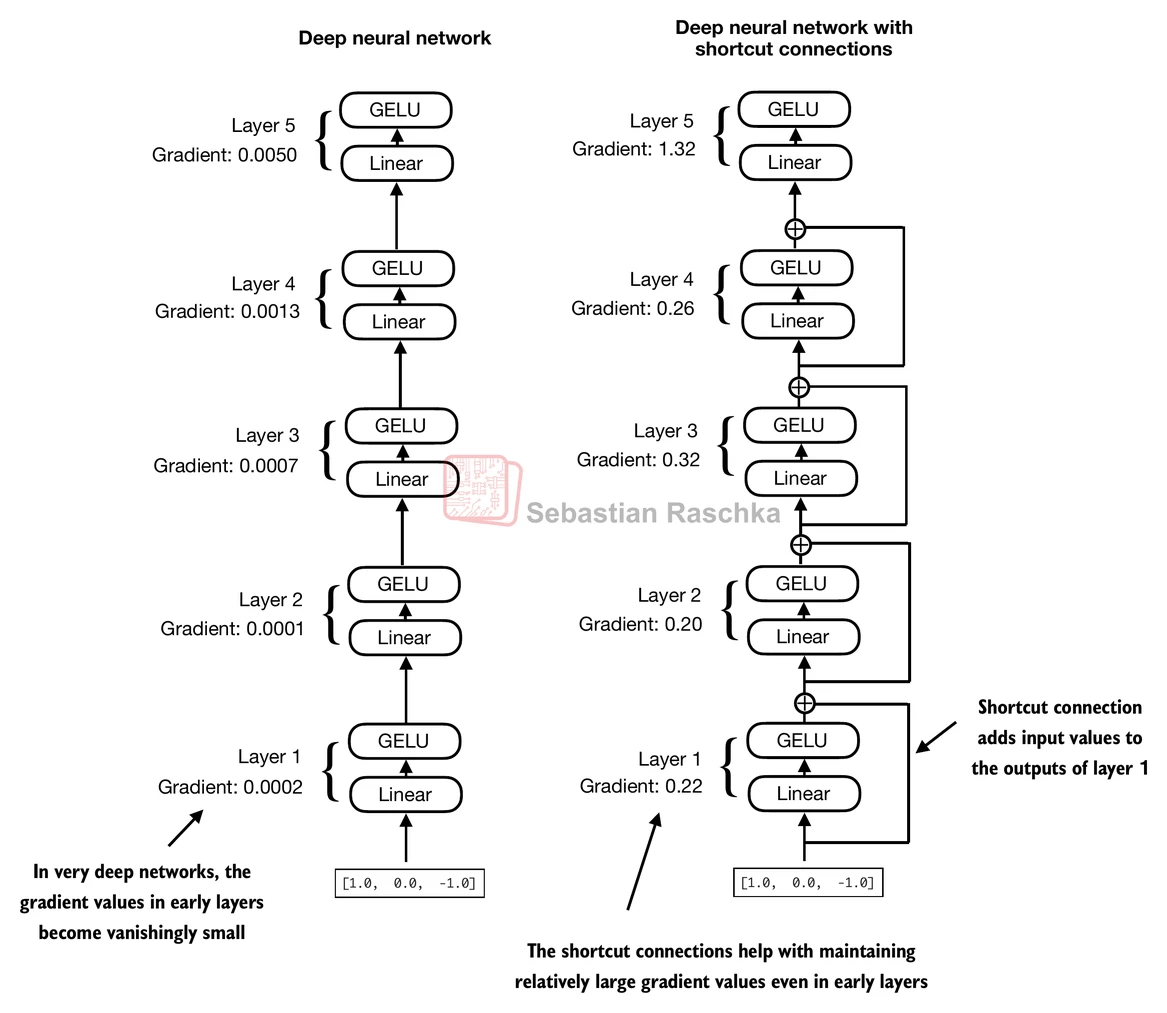

In [ ]:
# 用一个5层的深度网络演示：有/无残差(shortcut)连接对梯度传播的影响
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            # Compute the output of the current layer
            layer_output = layer(x)
            # Check if shortcut can be applied
            # 只有当输入输出形状相同时才能相加做残差连接(shortcut)
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output  # 残差连接：把本层输入直接加到本层输出上
            else:
                x = layer_output
        return x


# 辅助函数：跑一次前向+反向传播，打印每一层权重梯度的绝对值均值，
# 用来观察梯度是否会随着层数加深而“消失”（越靠前的层梯度越小）
def print_gradients(model, x):
    # Forward pass
    output = model(x)
    target = torch.tensor([[0.]])

    # Calculate loss based on how close the target
    # and output are
    loss = nn.MSELoss()
    loss = loss(output, target)

    # Backward pass to calculate the gradients
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            # Print the mean absolute gradient of the weights
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [ ]:
layer_sizes = [3, 3, 3, 3, 3, 1]

sample_input = torch.tensor([[1., 0., -1.]])

torch.manual_seed(123)
# 不使用shortcut(残差连接)的模型：预期越靠前的层梯度越小(梯度消失现象)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)
print_gradients(model_without_shortcut, sample_input)

In [ ]:
torch.manual_seed(123)
# 使用shortcut(残差连接)的模型：对比上一格，各层梯度应更加均衡、不再明显消失
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

4.5 Connecting attention and linear layers in a transformer block

In [ ]:
# If the `previous_chapters.py` file is not available locally,
# you can import it from the `llms-from-scratch` PyPI package.
# For details, see: https://github.com/rasbt/LLMs-from-scratch/tree/main/pkg
# E.g.,
# from llms_from_scratch.ch03 import MultiHeadAttention
# 中文说明：若当前目录下没有 previous_chapters.py（第3章实现的多头注意力等代码），
# 可改用上面注释中提示的 llms_from_scratch 这个PyPI包来导入 MultiHeadAttention。

from previous_chapters import MultiHeadAttention


# TransformerBlock：GPT的核心构建块，由“多头注意力子层”和“前馈网络子层”组成，
# 每个子层都遵循 Pre-LayerNorm + 残差连接(shortcut) 的结构：
#   x = x + Sublayer(LayerNorm(x))
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # 多头自注意力子层，输入输出维度都是emb_dim
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        # 前馈网络子层
        self.ff = FeedForward(cfg)
        # 两个子层各自使用独立的LayerNorm(Pre-Norm结构：先归一化再送入子层)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        # x 形状: [batch_size, num_tokens, emb_size]，全程保持不变
        shortcut = x  # 保存输入，用于残差连接
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back  # 残差相加，缓解深层网络的梯度消失问题

        # Shortcut connection for feed forward block
        shortcut = x  # 再次保存，用于第二个残差连接
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

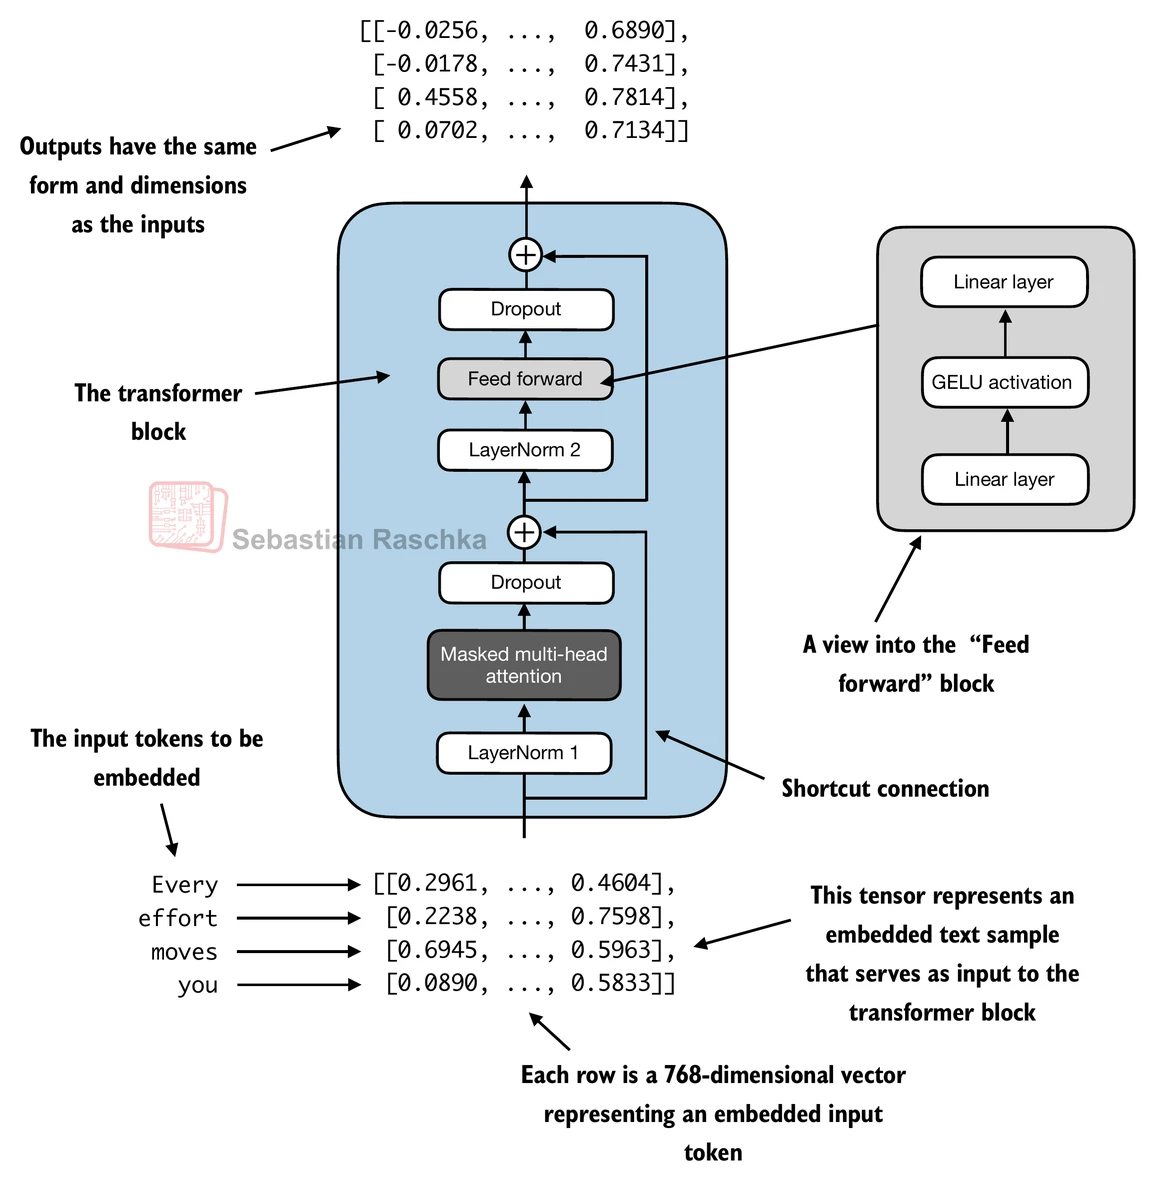

In [ ]:
torch.manual_seed(123)

x = torch.rand(2, 4, 768)  # Shape: [batch_size, num_tokens, emb_dim]
# 用随机张量测试TransformerBlock：验证输出形状与输入形状完全一致
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

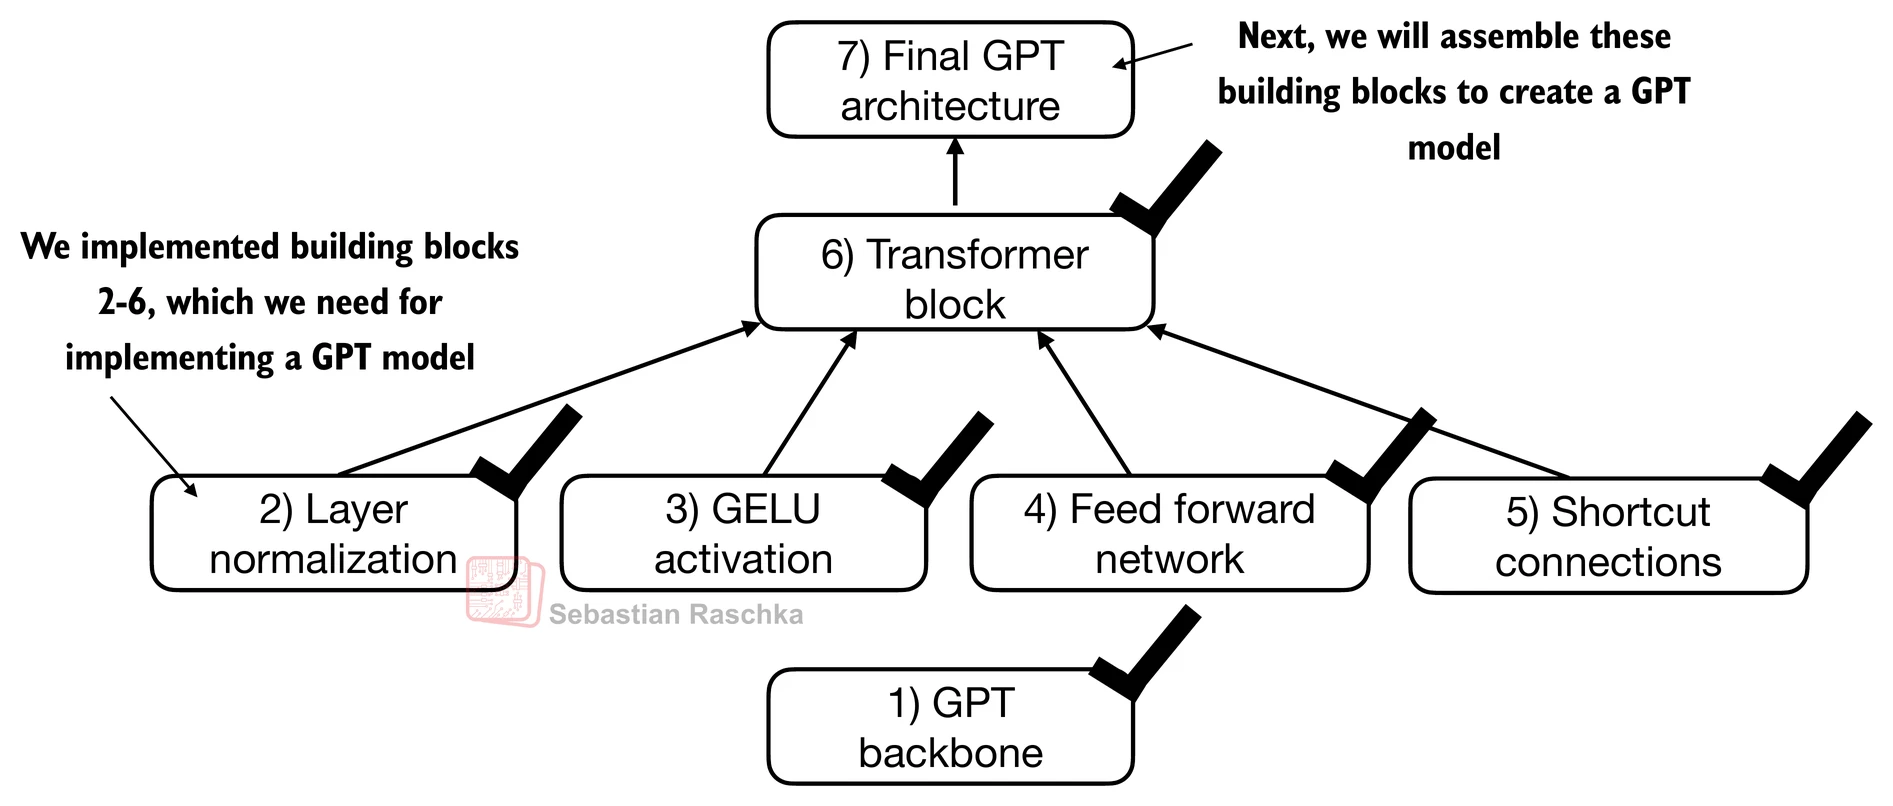

4.6 Coding the GPT model
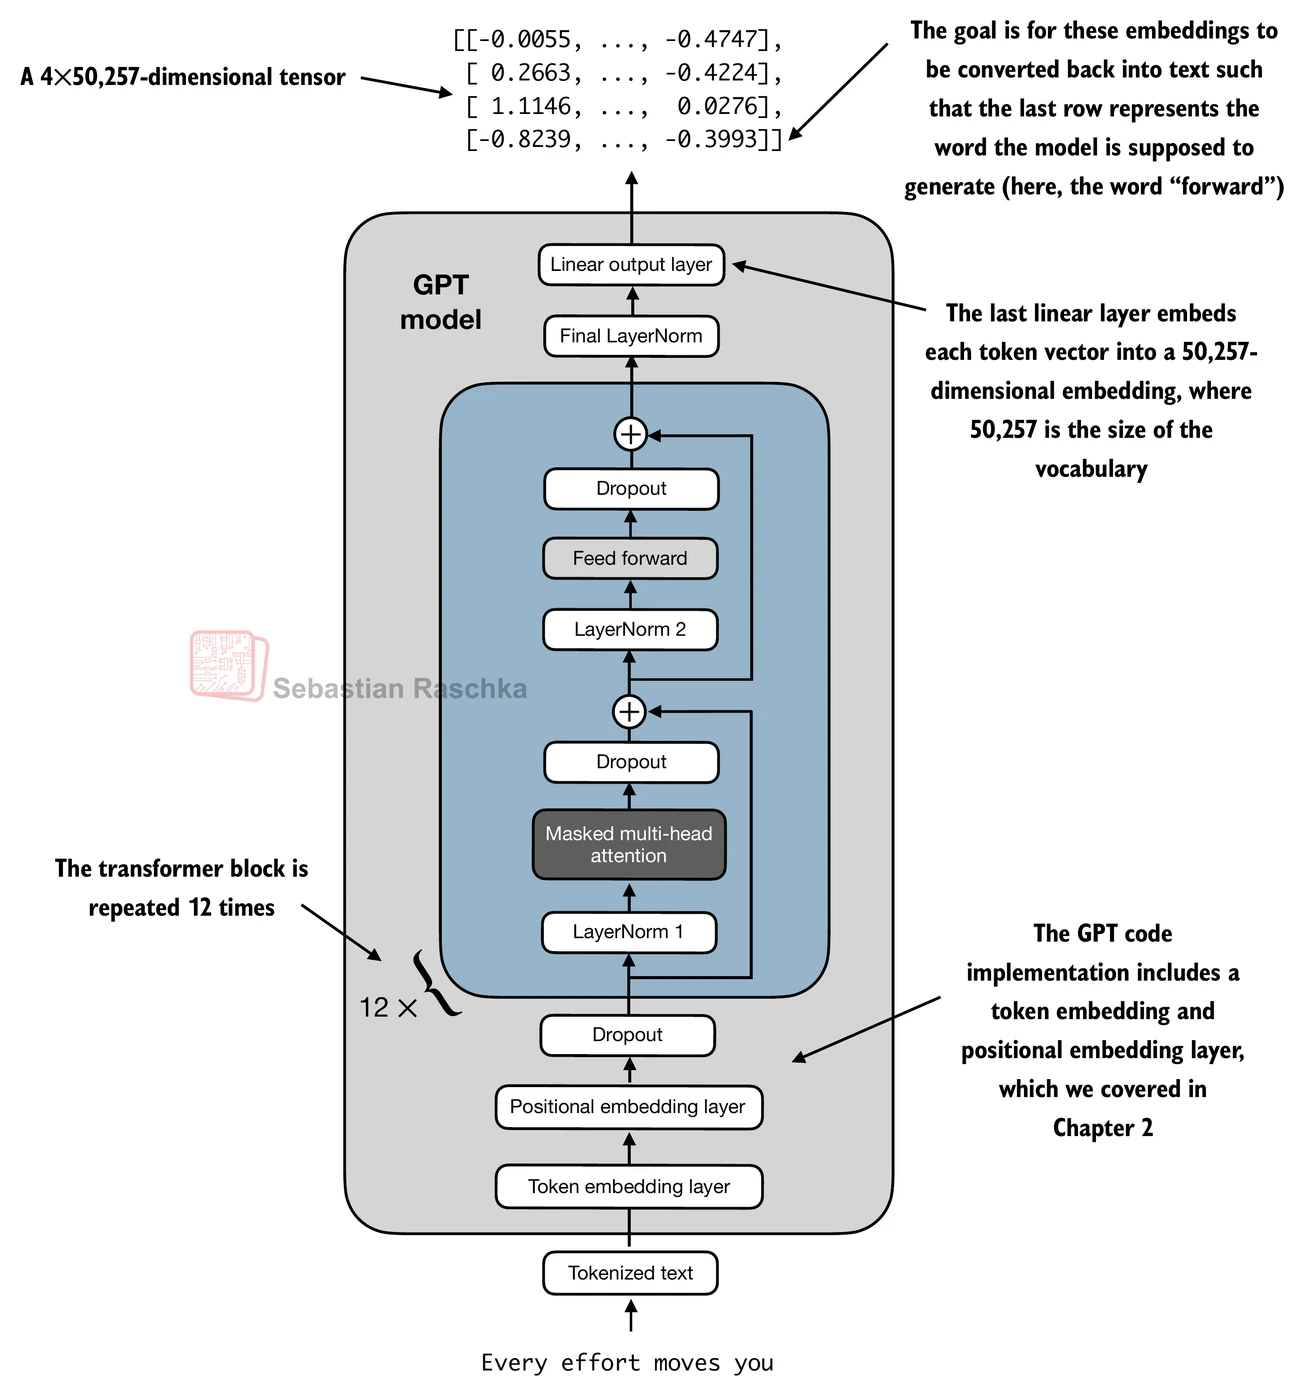

In [ ]:
# GPTModel：完整的GPT模型（把前面搭建的LayerNorm、FeedForward、TransformerBlock组合起来），
# 结构与DummyGPTModel完全一致，只是把占位模块替换成真正实现的模块
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # token嵌入表: [vocab_size, emb_dim]
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        # 位置嵌入表: [context_length, emb_dim]
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # 堆叠n_layers个真正的TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        # 输出头：把emb_dim维隐藏状态映射回vocab_size维logits
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        # in_idx 形状: [batch_size, seq_len]
        batch_size, seq_len = in_idx.shape
        # tok_embeds 形状: [batch_size, seq_len, emb_dim]
        tok_embeds = self.tok_emb(in_idx)
        # pos_embeds 形状: [seq_len, emb_dim]，与tok_embeds广播相加
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)  # 依次通过每个Transformer Block，形状不变
        x = self.final_norm(x)
        # logits 形状: [batch_size, seq_len, vocab_size]，即每个位置对整个词表的打分
        logits = self.out_head(x)
        return logits

In [ ]:
torch.manual_seed(123)
# 用真正的GPTModel对之前构造的batch(两句话的token id)做前向传播
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print("Input batch:\n", batch)
# 输出形状: [batch_size=2, seq_len, vocab_size=50257]
print("\nOutput shape:", out.shape)
print(out)

In [ ]:
# 统计模型总参数量（未考虑权重共享/tie weights），GPT-2实际做了权重共享，
# 因此这里算出的数值会比论文/官方说的"124M"略大，下面几格会做说明和修正
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

In [ ]:
# 查看token嵌入层和输出头的权重形状：两者形状相同 [vocab_size, emb_dim]，
# GPT-2原版让这两个权重共享(weight tying)，可以减少参数量
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

In [ ]:
# 若采用权重共享(输出头复用token嵌入层的权重)，则不需要为输出头单独计算参数，
# 因此从总参数量中减去输出头的参数个数，得到的数值才与"GPT-2 124M"的命名相符
total_params_gpt2 =  total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"Number of trainable parameters considering weight tying: {total_params_gpt2:,}")

In [ ]:
# Calculate the total size in bytes (assuming float32, 4 bytes per parameter)
# 按float32(每个参数4字节)估算模型占用的存储/显存大小
total_size_bytes = total_params * 4

# Convert to megabytes
total_size_mb = total_size_bytes / (1024 * 1024)

print(f"Total size of the model: {total_size_mb:.2f} MB")

4.7 Generating text
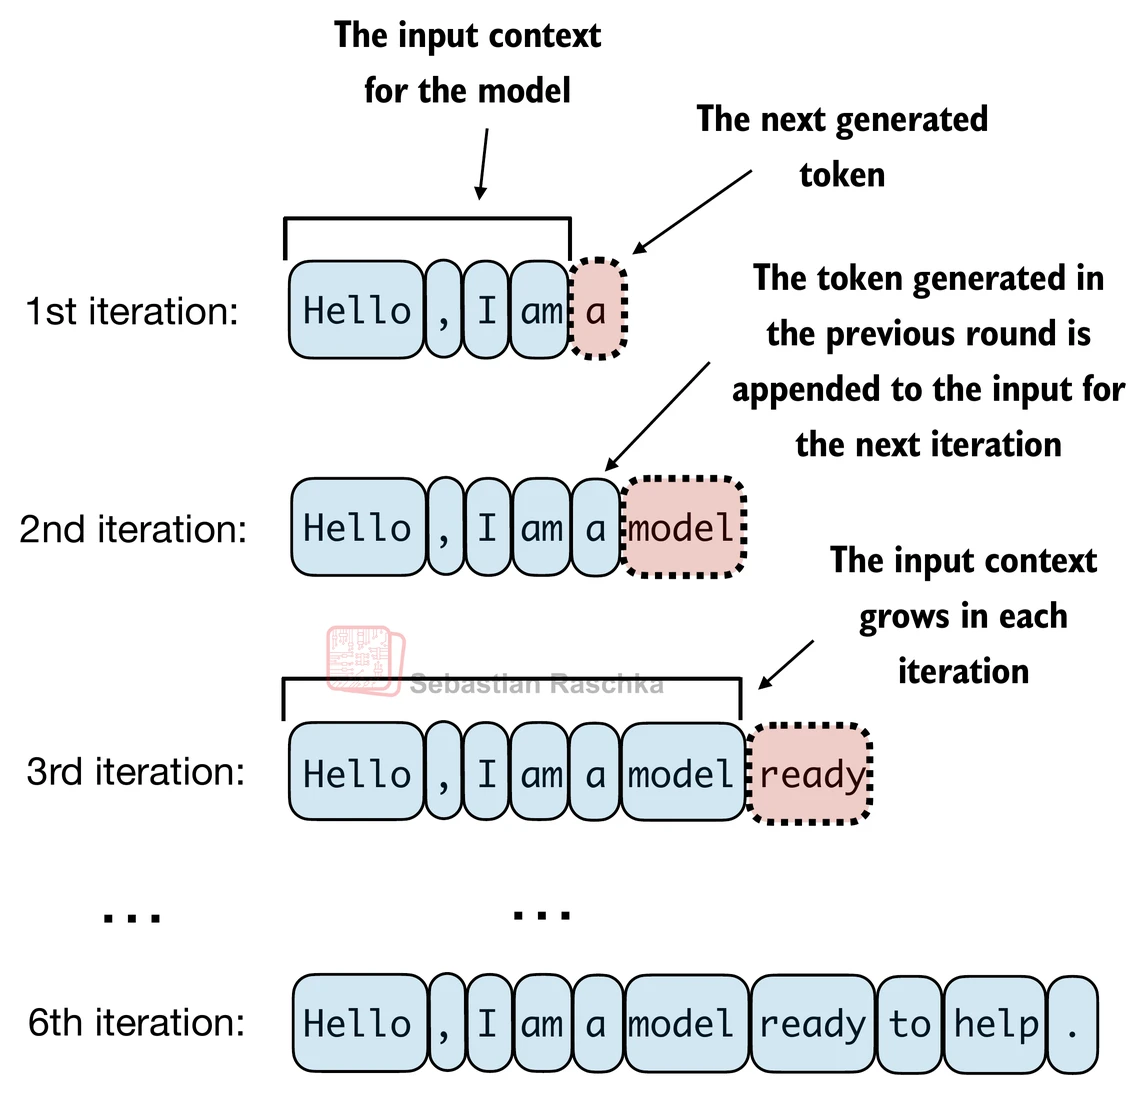
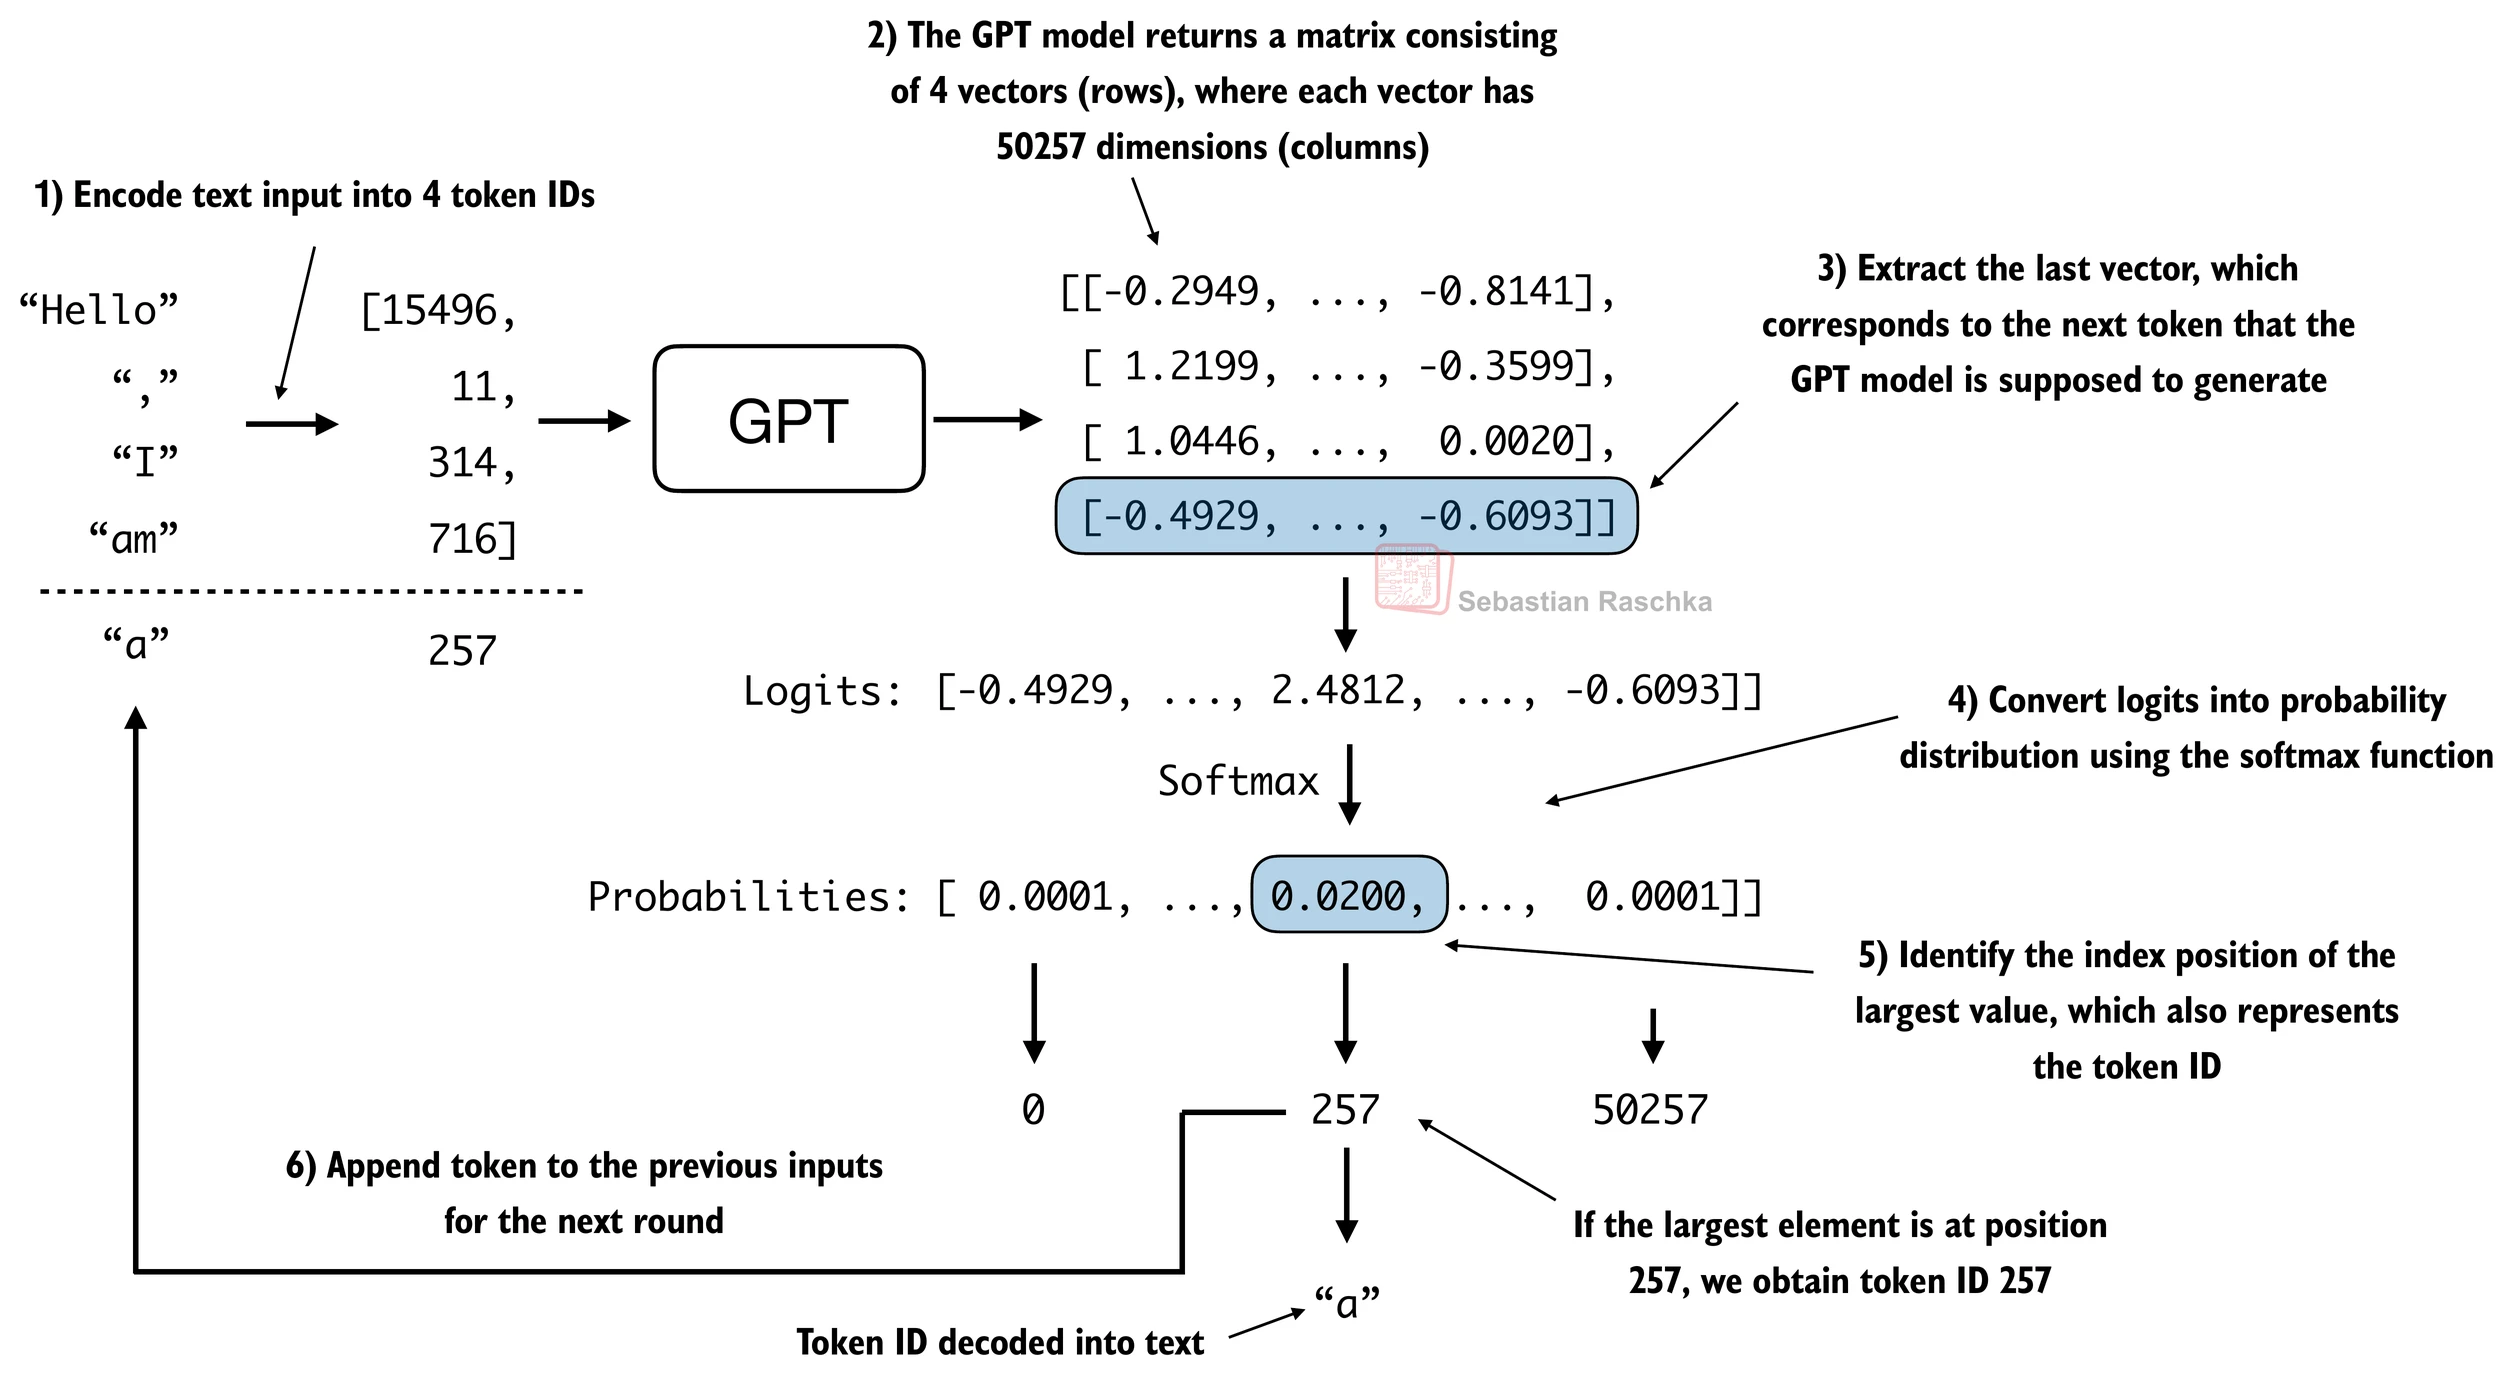

In [ ]:
# generate_text_simple：最简单的自回归文本生成函数，每步贪心(greedy)选取概率最大的下一个token
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context
    # idx 形状: [batch_size, n_tokens]，是当前已有的token id序列
    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        # 只保留最后context_size个token作为模型输入，避免超出模型支持的最大上下文长度
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        # 前向传播时不需要计算梯度(推理阶段)，节省显存/加速
        with torch.no_grad():
            logits = model(idx_cond)  # logits 形状: [batch, n_tokens, vocab_size]

        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        # 只关心序列最后一个位置的预测结果(下一个token的分布)
        logits = logits[:, -1, :]

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        # 贪心解码：直接取概率最大的那个token id，而不是按概率采样
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        # 把新生成的token拼接到序列末尾，序列长度+1，作为下一轮生成的输入
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

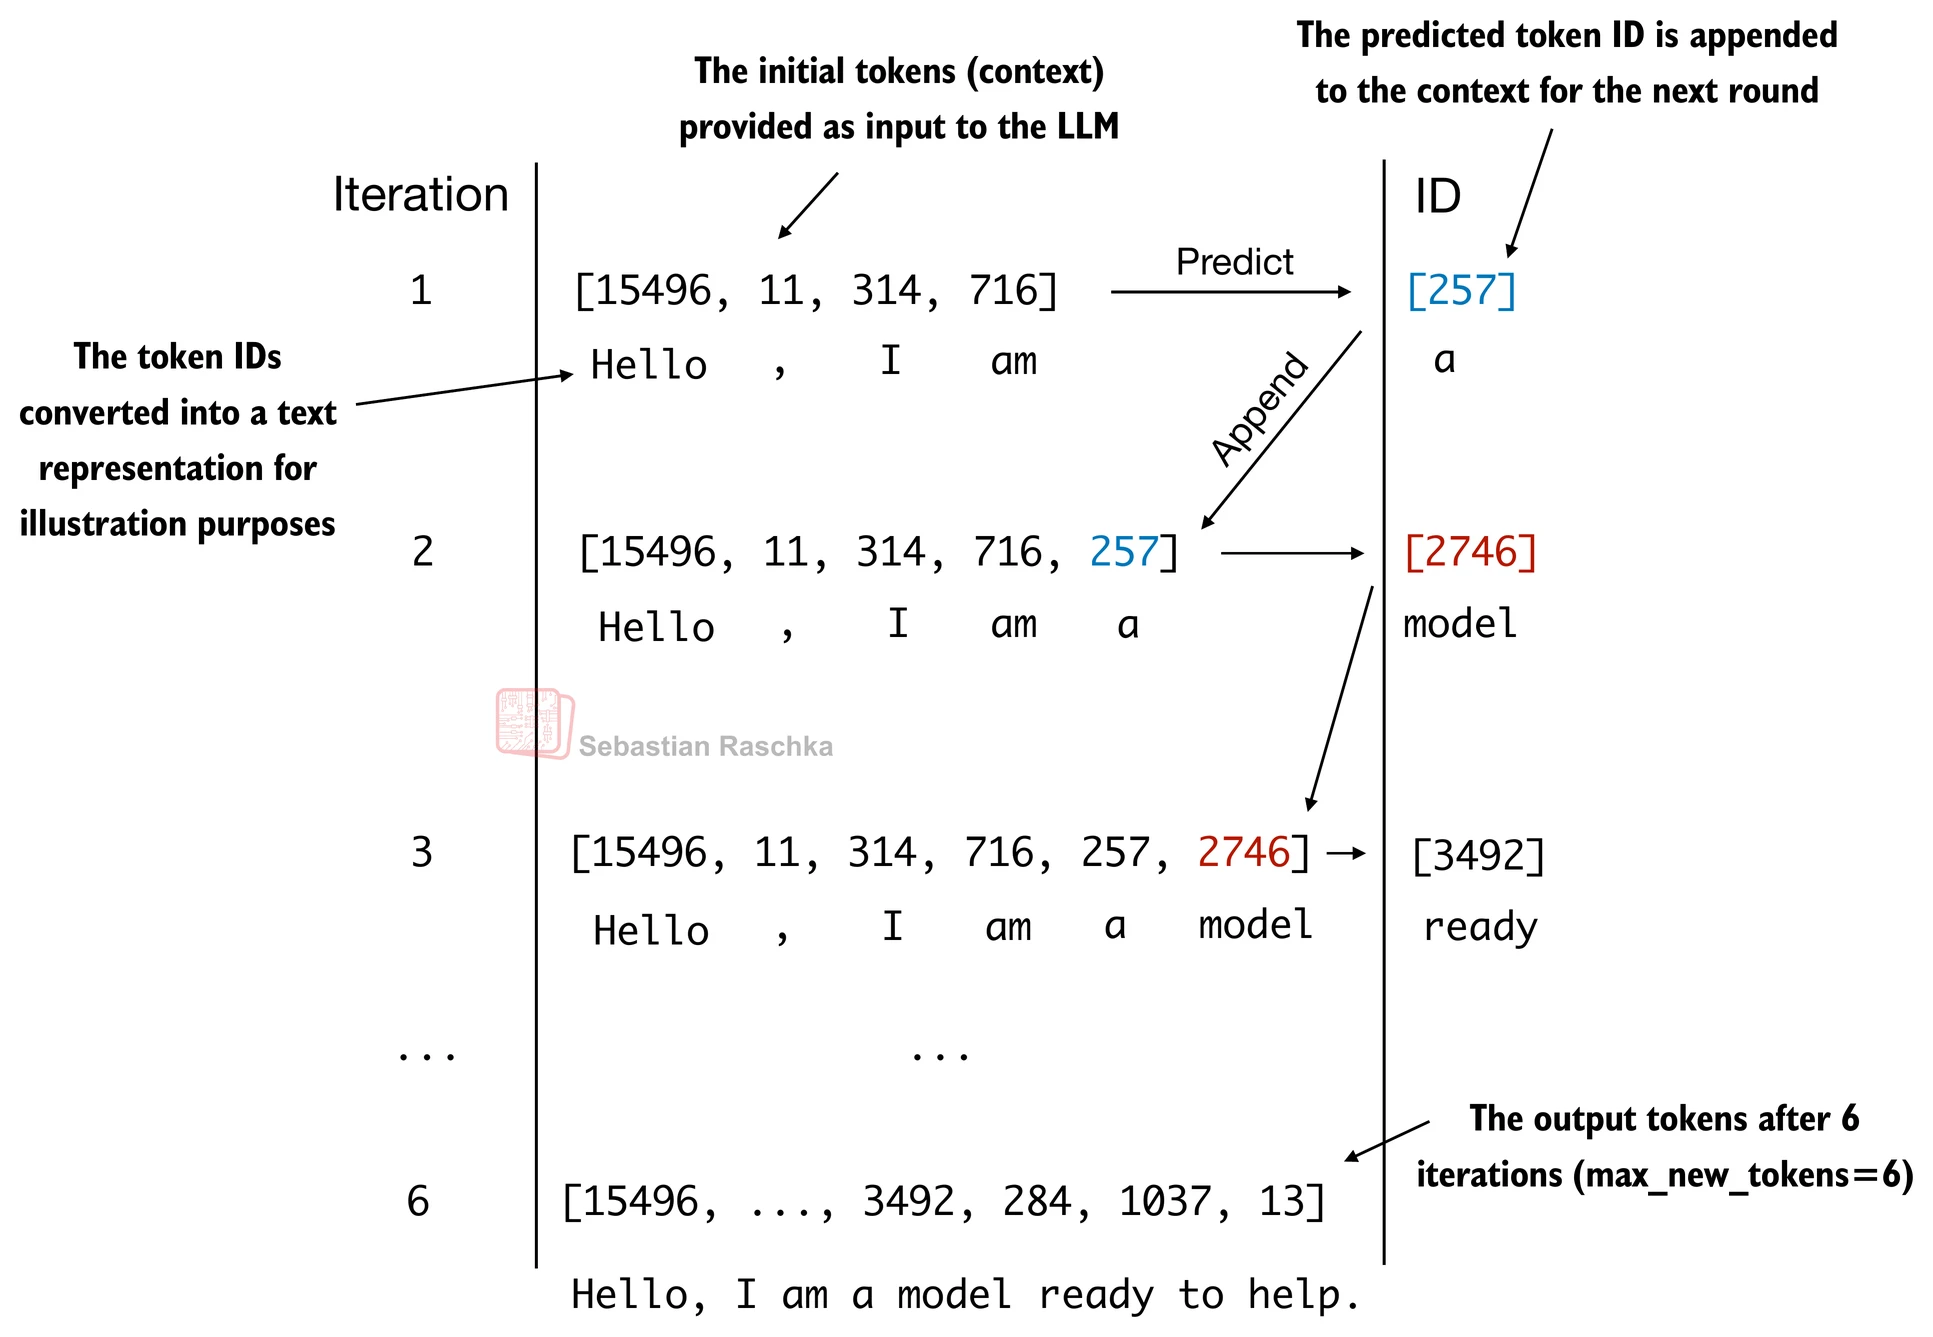

In [ ]:
start_context = "Hello, I am"

# 用同一个tokenizer把起始文本编码成token id列表
encoded = tokenizer.encode(start_context)
print("encoded:", encoded)

# unsqueeze(0)在最前面增加batch维度，形状从 [n_tokens] 变为 [1, n_tokens]，
# 因为模型的输入约定为 [batch_size, seq_len]
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)

In [ ]:
model.eval() # disable dropout
# 切换到eval模式，关闭dropout等只在训练时使用的随机性，保证生成结果确定

# 调用贪心解码函数，在"Hello, I am"后面继续生成6个新token
out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output:", out)
print("Output length:", len(out[0]))  # 原长度 + max_new_tokens

In [ ]:
# 把生成的token id序列解码回可读文本（此时模型未经训练，输出通常是乱码/无意义文本，属预期现象）
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)